# OVRO-LWA subband source metacatalog

Identify sources in OVRO-LWA **frequency-subband** FITS images with **PyBDSF**, then
fuse per-image catalogs into a **metacatalog** with one entry per unique sky position.

This is the same pipeline as `ovro_lwa_metacatalog.ipynb`, generalized from four
color products to **15 subbands labeled by frequency** (18–82 MHz). The highest
frequency seeds sequential association; lower subbands are attached in descending
frequency order.

Pipeline (library: `lwa_catalog.create` + Parquet I/O):

1. **Discover** FITS under `FITS_ROOT` (LST hour + subband from filenames).
2. **Detect** sources per image (`iter_detect_sources`); workers write each `sources_*.parquet` as it finishes.
3. **LST merge** within each subband (`merge_lst_metacatalog`) — one representative row per sky position.
4. **Band merge** sequential 82→78→…→18 MHz (`build_subband_metacatalog`) — flux stored only in `{field}_{subband}` columns; top-level `RA`/`DEC`/shape come from the highest-frequency subband present on each row.

Catalogs are written as **Parquet** under `OUTPUT_DIR` via `CatalogLayout`.
Set `REUSE_CACHED_CATALOGS = True` to skip PyBDSF / LST merge when caches exist.
Set `MIGRATE_LEGACY_CSV = True` once to convert old CSV/FITS catalog trees.

After changing the subband merge schema, rebuild `metacatalog.parquet` (delete the file or disable cache reuse for the fusion cell).


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, migrate_output_dir
from lwa_catalog.create import (
    build_subband_metacatalog,
    discover_fits_files,
    discovered_slots,
    iter_detect_sources,
    lst_hours_from_discovery,
    merge_lst_metacatalog,
)
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_all_lst_merged,
    read_sources_catalog,
    sources_cache_complete,
    write_lst_merged,
    write_metacatalog,
)

# --- user configuration ---------------------------------------------------
#FITS_ROOT = Path("/fast/claw")  # directory containing FITS images (searched recursively)
FITS_ROOT = Path("/lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827")
# Glob(s) relative to FITS_ROOT (rglob). Default: all .fits. Examples:
#   "??h_*MHz/*_I_deep_Taper_Robust-0.75*pbcorr*fits"
FITS_GLOB = "??h_*MHz/*_I_deep_Taper_Robust-0.75*pbcorr*fits"
OUTPUT_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband")  # Parquet catalog tree

# Upsample images before PyBDSF (finer pixel grid; WCS CDELT/CRPIX updated in detect)
BDSF_UPSAMPLE_FACTOR = 2

# PyBDSF detection parameters (ncores=1; parallelize across images instead)
BDSF_KW = dict(
    thresh="hard",
    thresh_isl=3.0,
    thresh_pix=4.0,
    rms_box=(128, 64),
    adaptive_rms_box=True,
    rms_box_bright=(32, 8),
    adaptive_thresh=50.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=1,
)

# Worker processes for iter_detect_sources (one PyBDSF run per image)
DETECT_N_JOBS = 10

# Optional subset of LST hour bins (e.g. ["01h", "02h"]). None = all discovered.
LST_HOURS_OVERRIDE: list[str] | None = None

# When True, skip PyBDSF / LST merge if matching Parquet files already exist
REUSE_CACHED_CATALOGS = True

# One-time CSV/FITS → Parquet migration (no-op if only Parquet is present)
MIGRATE_LEGACY_CSV = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)

if MIGRATE_LEGACY_CSV:
    migrated = migrate_output_dir(layout)
    print(f"Migrated {len(migrated)} legacy catalog file(s) under {OUTPUT_DIR}")


## Filename parsing

Discover FITS under `FITS_ROOT` and parse LST hour / frequency subband from filenames
(`lwa_catalog.create.discover`). Band names are the 15 frequency labels in
`COLOR_BANDS` below (e.g. `55MHz`).


In [2]:
# Explicit catalog constants (notebook-local; passed into library APIs below)

# Frequency subbands, low → high. SEED_BAND is the highest MHz (seeds association).

COLOR_BANDS = tuple(reversed((

    "18MHz",

    "23MHz",

    "27MHz",

    "32MHz",

    "36MHz",

    "41MHz",

    "46MHz",

    "50MHz",

    "55MHz",

    "59MHz",

    "64MHz",

    "69MHz",

    "73MHz",

    "78MHz",

    "82MHz",

)))

SEED_BAND = COLOR_BANDS[0]

ASSOC_BANDS = COLOR_BANDS[1:]

SUBBAND_FREQ_HZ = {b: float(b.removesuffix("MHz")) * 1e6 for b in COLOR_BANDS}



In [3]:
_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
fits_files = [
    m
    for m in discover_fits_files(FITS_ROOT, patterns=_fits_patterns)
    if m.band in COLOR_BANDS
]
_discovered_lst_hours = lst_hours_from_discovery(fits_files)
LST_HOURS = list(LST_HOURS_OVERRIDE) if LST_HOURS_OVERRIDE is not None else _discovered_lst_hours
fits_by_slot = discovered_slots(fits_files)
summary = pd.DataFrame(
    {
        "path": [m.path.name for m in fits_files],
        "lst_hour": [m.lst_hour for m in fits_files],
        "band": [m.band for m in fits_files],
        "time_key": [m.time_key for m in fits_files],
    }
)
print(f"Found {len(fits_files)} FITS files under {FITS_ROOT} matching {list(_fits_patterns)}")
print(
    f"Subbands in use ({len(COLOR_BANDS)}): {', '.join(COLOR_BANDS)}"
)
print(f"  seed: {SEED_BAND}; associate: {', '.join(ASSOC_BANDS)}")
missing = [b for b in COLOR_BANDS if b not in {m.band for m in fits_files}]
if missing:
    print(f"  WARNING: no FITS for {', '.join(missing)}")
print(
    f"LST hours from discovery ({len(_discovered_lst_hours)}): "
    f"{', '.join(_discovered_lst_hours)}"
)
if LST_HOURS_OVERRIDE is not None:
    print(f"LST hours in use (override): {', '.join(LST_HOURS)}")
else:
    print(f"LST hours in use (all discovered): {', '.join(LST_HOURS)}")
summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Found 330 FITS files under /lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827 matching ['??h_*MHz/*_I_deep_Taper_Robust-0.75*pbcorr*fits']
Subbands in use (15): 82MHz, 78MHz, 73MHz, 69MHz, 64MHz, 59MHz, 55MHz, 50MHz, 46MHz, 41MHz, 36MHz, 32MHz, 27MHz, 23MHz, 18MHz
  seed: 82MHz; associate: 78MHz, 73MHz, 69MHz, 64MHz, 59MHz, 55MHz, 50MHz, 46MHz, 41MHz, 36MHz, 32MHz, 27MHz, 23MHz, 18MHz
LST hours from discovery (22): 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h
LST hours in use (all discovered): 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h


,path,lst_hour,band,time_key
0,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,18MHz,None
1,23MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,23MHz,None
2,27MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,27MHz,None
3,32MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,32MHz,None
4,36MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,01h,36MHz,None
...,...,...,...,...
325,64MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,22h,64MHz,None
326,69MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,22h,69MHz,None
327,73MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,22h,73MHz,None
328,78MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,22h,78MHz,None


## PyBDSF source detection

Detect sources per image with PyBDSF (`lwa_catalog.create.detect`).
Images are upsampled by `BDSF_UPSAMPLE_FACTOR` (default 2×) before detection.
`GAUL_COLUMNS` and `BDSF_KW` are notebook-local; cache helpers wrap Parquet I/O.


In [4]:
GAUL_COLUMNS = [
    "RA",
    "DEC",
    "S_Code",
    "Total_flux",
    "E_Total_flux",
    "Peak_flux",
    "E_Peak_flux",
    "Maj",
    "Min",
    "PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
    "Resid_Isl_rms",
    "Resid_Isl_mean",
]


def all_sources_cached() -> bool:
    """True when every discovered (lst, band) slot has a sources Parquet file."""
    return sources_cache_complete(layout, sorted(fits_by_slot))


def all_lst_merged_cached() -> bool:
    """True when every color band has an LST-merged Parquet file."""
    return lst_merged_cache_complete(layout, COLOR_BANDS)


def load_sources_catalog(lst_hour: str, band: str) -> pd.DataFrame:
    """Load a per-image sources Parquet catalog, backfilling beam from the FITS image."""
    meta = fits_by_slot[(lst_hour, band)]
    return read_sources_catalog(layout, lst_hour, band, fits_path=meta.path)


def load_per_image_catalogs_from_disk() -> dict[tuple[str, str], pd.DataFrame]:
    """Load all per-image catalogs from OUTPUT_DIR when every slot is cached."""
    catalogs: dict[tuple[str, str], pd.DataFrame] = {}
    for lst_hour, band in sorted(fits_by_slot):
        catalogs[(lst_hour, band)] = load_sources_catalog(lst_hour, band)
    return catalogs


def load_lst_merged_from_disk() -> dict[str, pd.DataFrame]:
    """Load LST-merged per-band catalogs from OUTPUT_DIR."""
    return read_all_lst_merged(layout, COLOR_BANDS)


In [5]:
per_image_catalogs: dict[tuple[str, str], pd.DataFrame] = {}
todo = []

for (lst_hour, band), meta in sorted(fits_by_slot.items()):
    key = (lst_hour, band)
    out_path = layout.sources(lst_hour, band)

    if REUSE_CACHED_CATALOGS and out_path.is_file():
        catalog = load_sources_catalog(lst_hour, band)
        per_image_catalogs[key] = catalog
        print(f"Cached {key}: {len(catalog)} sources <- {out_path.name}")
        continue

    todo.append((key, meta))

if todo:
    todo_metas = [meta for _, meta in todo]
    todo_paths = [layout.sources(meta.lst_hour, meta.band) for meta in todo_metas]
    for meta, out_path, n_sources in iter_detect_sources(
        todo_metas,
        todo_paths,
        n_jobs=DETECT_N_JOBS,
        bdsf_kw=BDSF_KW,
        gaul_columns=GAUL_COLUMNS,
        upsample_factor=BDSF_UPSAMPLE_FACTOR,
    ):
        key = (meta.lst_hour, meta.band)
        per_image_catalogs[key] = load_sources_catalog(meta.lst_hour, meta.band)
        print(f"Detected {key}: {n_sources} sources -> {out_path.name}")


Cached ('01h', '18MHz'): 1873 sources <- sources_01h_18MHz.parquet
Cached ('01h', '23MHz'): 4519 sources <- sources_01h_23MHz.parquet
Cached ('01h', '27MHz'): 6742 sources <- sources_01h_27MHz.parquet
Cached ('01h', '32MHz'): 9281 sources <- sources_01h_32MHz.parquet
Cached ('01h', '36MHz'): 12301 sources <- sources_01h_36MHz.parquet
Cached ('01h', '41MHz'): 16966 sources <- sources_01h_41MHz.parquet
Cached ('01h', '46MHz'): 19618 sources <- sources_01h_46MHz.parquet
Cached ('01h', '50MHz'): 22450 sources <- sources_01h_50MHz.parquet
Cached ('01h', '55MHz'): 25048 sources <- sources_01h_55MHz.parquet
Cached ('01h', '59MHz'): 25926 sources <- sources_01h_59MHz.parquet
Cached ('01h', '64MHz'): 28794 sources <- sources_01h_64MHz.parquet
Cached ('01h', '69MHz'): 28473 sources <- sources_01h_69MHz.parquet
Cached ('01h', '73MHz'): 28103 sources <- sources_01h_73MHz.parquet
Cached ('01h', '78MHz'): 29164 sources <- sources_01h_78MHz.parquet
Cached ('01h', '82MHz'): 23071 sources <- sources_01

## Per-LST source elevation

Each `sources_{lst}_{subband}.parquet` catalog holds detections from one LST hour and
one frequency subband. Source **elevation** is computed at OVRO (zenith at
RA = LST, Dec = site latitude) using the same formula as LST-merge representative
selection (`catalog_elevation_deg`).

The grid below has one histogram per catalog: rows = LST hour, columns = subband
(high → low MHz, matching `COLOR_BANDS`).

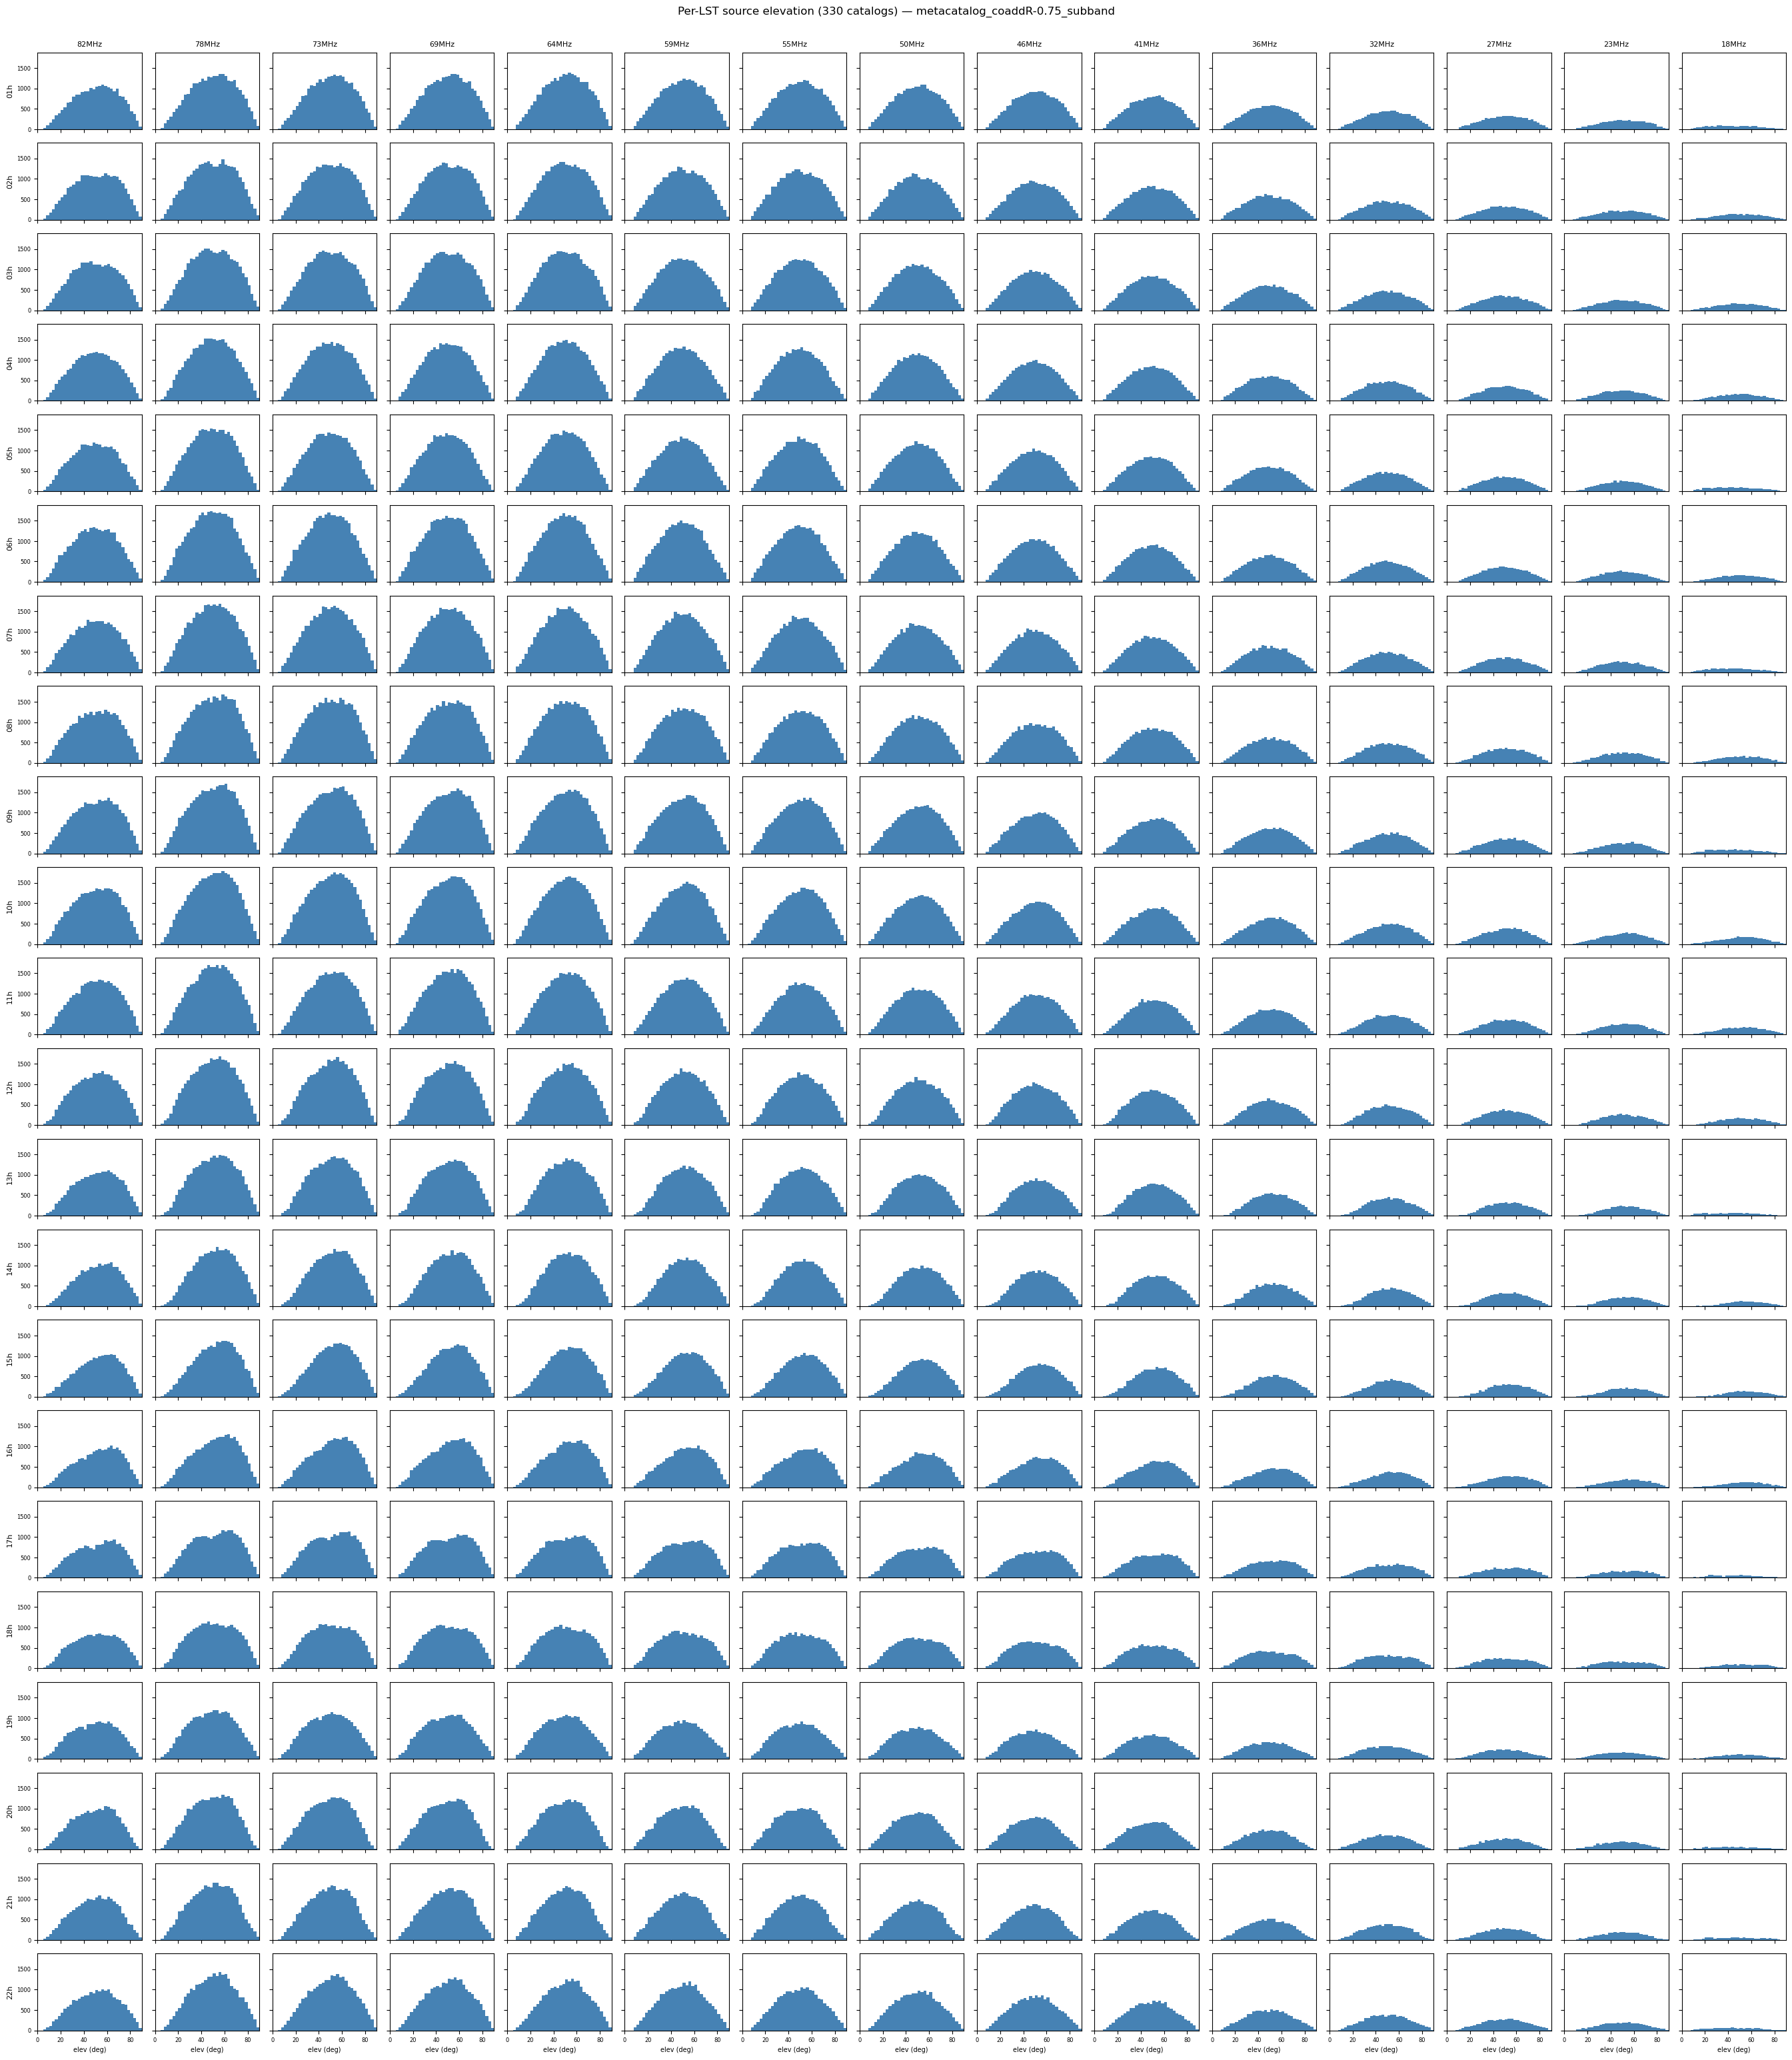

Plotted 330 catalogs (22 LST × 15 subbands)


In [6]:
import re

import matplotlib.pyplot as plt
import numpy as np

from lwa_catalog.create.merge import catalog_elevation_deg

SOURCES_PATTERN = re.compile(r"sources_(\d+h)_(\d+MHz)\.parquet$")
ELEVATION_BIN_DEG = 2.5

source_paths: dict[tuple[str, str], Path] = {}
for path in sorted(OUTPUT_DIR.glob("sources_??h_??MHz.parquet")):
    match = SOURCES_PATTERN.match(path.name)
    if match is None:
        continue
    source_paths[(match.group(1), match.group(2))] = path

lst_hours = sorted({lst for lst, _ in source_paths}, key=lambda h: int(h.rstrip("h")))
bands_plot = [b for b in COLOR_BANDS if any(k[1] == b for k in source_paths)]
if not bands_plot:
    bands_plot = sorted(
        {band for _, band in source_paths},
        key=lambda b: int(b.removesuffix("MHz")),
        reverse=True,
    )

elev_bins = np.arange(0.0, 90.0 + ELEVATION_BIN_DEG, ELEVATION_BIN_DEG)
n_lst, n_band = len(lst_hours), len(bands_plot)
fig, axes = plt.subplots(
    n_lst,
    n_band,
    figsize=(1.8 * n_band, 1.4 * n_lst),
    sharex=True,
    sharey=True,
    squeeze=False,
)

for i, lst_hour in enumerate(lst_hours):
    for j, band in enumerate(bands_plot):
        ax = axes[i, j]
        path = source_paths.get((lst_hour, band))
        if path is None:
            ax.axis("off")
            continue

        catalog = pd.read_parquet(path, columns=["RA", "DEC", "lst_hour"])
        elevation = catalog_elevation_deg(catalog)
        elevation = elevation[np.isfinite(elevation)]
        ax.hist(elevation, bins=elev_bins, color="steelblue", edgecolor="none")
        ax.set_xlim(0.0, 90.0)

        if i == 0:
            ax.set_title(band, fontsize=8)
        if j == 0:
            ax.set_ylabel(lst_hour, fontsize=8)
        ax.tick_params(labelsize=6)

for j in range(n_band):
    axes[-1, j].set_xlabel("elev (deg)", fontsize=7)

fig.suptitle(
    f"Per-LST source elevation ({len(source_paths)} catalogs) — {OUTPUT_DIR.name}",
    fontsize=12,
    y=1.002,
)
fig.tight_layout()
plt.show()

print(f"Plotted {len(source_paths)} catalogs ({n_lst} LST × {n_band} subbands)")

## Metacatalog fusion



**LST merge** (within each subband): one representative row per sky position

(`merge_lst_metacatalog`).



**Subband merge** (`build_subband_metacatalog`): sequential association from

`SEED_BAND` (highest MHz) downward. Each row stores flux only in

`Peak_flux_{subband}`, `Total_flux_{subband}`, and error columns — no top-level

`Peak_flux`/`Total_flux` and no per-subband astrometry/shape columns. Top-level

`RA`/`DEC`/Gaussian shape come from the **highest-frequency subband present**

(`astrometry_band`). Merge-time spectral indices are **not** computed here; use

`notebooks/metacatalog_spectral_modeling.ipynb` for Taylor-fit spectral modeling.



In [7]:
from lwa_catalog.constants import SUBBAND_METACATALOG_FLUX_FIELDS, SUBBAND_METACATALOG_REQUIRED_COLUMNS

assert SUBBAND_METACATALOG_FLUX_FIELDS == (
    "Peak_flux",
    "Total_flux",
    "E_Peak_flux",
    "E_Total_flux",
)


def per_subband_flux_columns(bands: tuple[str, ...] = COLOR_BANDS) -> list[str]:
    """Metacatalog column names for per-subband flux preservation."""
    cols: list[str] = []
    for band in bands:
        for field in SUBBAND_METACATALOG_FLUX_FIELDS:
            cols.append(f"{field}_{band}")
    return cols


In [8]:
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and all_lst_merged_cached():
    lst_merged = load_lst_merged_from_disk()
    for band in COLOR_BANDS:
        print(
            f"LST merge ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    if not per_image_catalogs and REUSE_CACHED_CATALOGS and all_sources_cached():
        per_image_catalogs.update(load_per_image_catalogs_from_disk())
        print(f"Loaded {len(per_image_catalogs)} per-image catalogs from {OUTPUT_DIR}")

    for band in COLOR_BANDS:
        band_catalogs = [
            per_image_catalogs[(lst, band)]
            for lst in LST_HOURS
            if (lst, band) in per_image_catalogs
        ]
        merged = merge_lst_metacatalog(band_catalogs, band=band)
        lst_merged[band] = merged
        out_path = write_lst_merged(merged, layout, band)
        print(f"LST merge ({band}): {len(merged)} sources -> {out_path}")

metacatalog = build_subband_metacatalog(
    lst_merged,
    seed_band=SEED_BAND,
    assoc_bands=ASSOC_BANDS,
    color_bands=COLOR_BANDS,
    band_freq_hz=SUBBAND_FREQ_HZ,
)
meta_path = write_metacatalog(
    metacatalog,
    layout,
    required=SUBBAND_METACATALOG_REQUIRED_COLUMNS,
    schema=None,
)

if per_image_catalogs:
    n_inputs = sum(len(df) for df in per_image_catalogs.values())
    input_desc = f"{n_inputs} per-image detections"
else:
    n_inputs = sum(int(df["n_lst_contributions"].sum()) for df in lst_merged.values())
    input_desc = f"{n_inputs} LST-merged rows (cached)"
print(f"\nGlobal metacatalog: {len(metacatalog)} sources from {input_desc}")
print(f"Wrote {meta_path}")
print(
    f"Per-subband flux columns ({len(per_subband_flux_columns())}): "
    f"{', '.join(per_subband_flux_columns()[:4])}, ..."
)
metacatalog.head(10)


LST merge (82MHz): loaded 93552 sources from metacatalog_lst_82MHz.parquet
LST merge (78MHz): loaded 110217 sources from metacatalog_lst_78MHz.parquet
LST merge (73MHz): loaded 104228 sources from metacatalog_lst_73MHz.parquet
LST merge (69MHz): loaded 99443 sources from metacatalog_lst_69MHz.parquet
LST merge (64MHz): loaded 95244 sources from metacatalog_lst_64MHz.parquet
LST merge (59MHz): loaded 81115 sources from metacatalog_lst_59MHz.parquet
LST merge (55MHz): loaded 74589 sources from metacatalog_lst_55MHz.parquet
LST merge (50MHz): loaded 66173 sources from metacatalog_lst_50MHz.parquet
LST merge (46MHz): loaded 57551 sources from metacatalog_lst_46MHz.parquet
LST merge (41MHz): loaded 49228 sources from metacatalog_lst_41MHz.parquet
LST merge (36MHz): loaded 34596 sources from metacatalog_lst_36MHz.parquet
LST merge (32MHz): loaded 27130 sources from metacatalog_lst_32MHz.parquet
LST merge (27MHz): loaded 20497 sources from metacatalog_lst_27MHz.parquet
LST merge (23MHz): load

,meta_id,origin_band,bands_present,RA,DEC,Maj,Min,PA,DC_Maj,DC_Min,...,source_file_59MHz,source_file_55MHz,source_file_50MHz,source_file_46MHz,source_file_41MHz,source_file_36MHz,source_file_32MHz,source_file_27MHz,source_file_23MHz,source_file_18MHz
0,134592,59MHz,"59MHz,23MHz,18MHz",50.238426,41.700230,1.024100,0.151483,174.693564,0.866252,0.102365,...,59MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
1,7,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,50MH...",49.931915,41.516249,0.112163,0.101283,62.806622,0.066462,0.054576,...,59MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,55MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,50MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,46MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,41MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,36MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,NaN,23MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
2,93560,78MHz,"78MHz,69MHz,64MHz,23MHz,18MHz",49.702655,41.296361,0.341893,0.050005,126.855850,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
3,134527,59MHz,"59MHz,18MHz",68.967301,29.460631,0.197460,0.059312,144.658354,0.000000,0.000000,...,59MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
4,1035,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,50MHz,36MH...",68.926554,29.690979,0.288427,0.109929,49.281993,0.000000,0.000000,...,59MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,50MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,NaN,36MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,NaN,23MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
5,31,82MHz,"82MHz,32MHz,27MHz,23MHz,18MHz",69.089666,29.541931,0.139083,0.069276,144.730921,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,32MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,27MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,23MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
6,8,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,50MH...",69.215699,29.674406,0.093479,0.077642,5.978519,0.000000,0.000000,...,59MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,55MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,50MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,46MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,41MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,32MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,27MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,23MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
7,445,82MHz,"82MHz,69MHz,64MHz,59MHz,50MHz,36MHz,32MHz,27MH...",69.059195,29.705322,0.162502,0.096823,16.411216,0.133954,0.044737,...,59MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,50MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,NaN,36MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,32MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,27MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,23MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
8,36,82MHz,"82MHz,69MHz,64MHz,55MHz,41MHz,36MHz,27MHz,23MH...",50.219797,-37.187395,0.302863,0.206954,27.395378,0.000000,0.000000,...,NaN,55MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,NaN,41MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,36MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,27MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,23MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,18MHz_I_deep_Taper_Robust-0.75_pbcorr_dewarped...
9,107,82MHz,"82MHz,36MHz,27MHz,23MHz,18MHz",50.395129,-36.948102,0.413079,0.063885,49.907074,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,36MHz_I_deep_Taper_Robust-0.75_pbco

In [9]:
# LST merge yield (seed subband)
seed_lst = lst_merged[SEED_BAND]
multi_lst = seed_lst[seed_lst["n_lst_contributions"] > 1].sort_values(
    "n_lst_contributions", ascending=False
)
print(f"{SEED_BAND} sources after LST merge: {len(seed_lst)}")
print(f"  seen in multiple LST hours: {len(multi_lst)}")
if len(multi_lst):
    display(
        multi_lst.head(10)[
            ["RA", "DEC", "Peak_flux", "n_lst_contributions", "lst_hours", "representative_lst"]
        ]
    )

# Global subband merge
print(f"\nGlobal rows by origin_band:")
print(metacatalog["origin_band"].value_counts())

assoc_cols = [f"n_assoc_{b}" for b in ASSOC_BANDS if f"n_assoc_{b}" in metacatalog.columns]
seed_with_assoc = metacatalog[
    (metacatalog["origin_band"] == SEED_BAND)
    & (metacatalog[assoc_cols].max(axis=1) > 0)
]
print(
    f"{SEED_BAND}-seeded rows with at least one other-subband association: "
    f"{len(seed_with_assoc)}"
)

summary_cols = [
    c
    for c in [
        "meta_id",
        "RA",
        "DEC",
        "astrometry_band",
        "origin_band",
        "bands_present",
        "lst_hours",
    ]
    if c in metacatalog.columns
]
display(metacatalog.head(10)[summary_cols])

flux_cols = ["meta_id", "astrometry_band", "bands_present", *per_subband_flux_columns()]
flux_cols = [c for c in flux_cols if c in metacatalog.columns]
print(f"\nPer-subband flux columns ({len(flux_cols) - 3} flux fields × {len(COLOR_BANDS)} subbands):")
display(metacatalog.head(10)[flux_cols])


82MHz sources after LST merge: 93552
  seen in multiple LST hours: 73676


,RA,DEC,Peak_flux,n_lst_contributions,lst_hours,representative_lst
399,6.484856,64.166965,13.152422,96,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",01h
46,319.565274,60.829569,47.510710,85,"01h,02h,03h,04h,05h,06h,11h,12h,13h,14h,15h,16...",21h
165,280.289544,79.789960,21.535948,84,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",19h
51203,174.786846,65.940248,0.849048,73,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",12h
333,315.959056,76.503067,14.650701,71,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",21h
15083,117.266655,55.859478,2.065214,67,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",08h
28,350.937709,58.914862,60.592898,66,"01h,02h,03h,04h,05h,06h,07h,08h,14h,15h,16h,17...",22h
10,212.816970,52.210322,92.239816,66,"06h,07h,08h,09h,10h,11h,12h,13h,14h,15h,16h,17...",14h
852,71.980404,45.019103,9.146265,65,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",05h
10495,31.578478,64.888870,2.570583,64,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",02h



Global rows by origin_band:
origin_band
82MHz    93552
78MHz    25524
73MHz     7972
69MHz     4486
64MHz     2989
59MHz     1391
55MHz      791
50MHz      592
46MHz      380
18MHz      299
41MHz      248
36MHz      196
32MHz      141
27MHz      116
23MHz       55
Name: count, dtype: int64
82MHz-seeded rows with at least one other-subband association: 91608


,meta_id,RA,DEC,astrometry_band,origin_band,bands_present,lst_hours
0,134592,50.238426,41.700230,59MHz,59MHz,"59MHz,23MHz,18MHz",10h
1,7,49.931915,41.516249,82MHz,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,50MH...","01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,20h,21..."
2,93560,49.702655,41.296361,78MHz,78MHz,"78MHz,69MHz,64MHz,23MHz,18MHz",10h
3,134527,68.967301,29.460631,59MHz,59MHz,"59MHz,18MHz",10h
4,1035,68.926554,29.690979,82MHz,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,50MHz,36MH...",10h
5,31,69.089666,29.541931,82MHz,82MHz,"82MHz,32MHz,27MHz,23MHz,18MHz",10h
6,8,69.215699,29.674406,82MHz,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,50MH...","01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,22h"
7,445,69.059195,29.705322,82MHz,82MHz,"82MHz,69MHz,64MHz,59MHz,50MHz,36MHz,32MHz,27MH...","01h,02h,03h,04h,09h"
8,36,50.219797,-37.187395,82MHz,82MHz,"82MHz,69MHz,64MHz,55MHz,41MHz,36MHz,27MHz,23MH...",01h
9,107,50.395129,-36.948102,82MHz,82MHz,"82MHz,36MHz,27MHz,23MHz,18MHz",01h



Per-subband flux columns (60 flux fields × 15 subbands):


,meta_id,astrometry_band,bands_present,Peak_flux_82MHz,Total_flux_82MHz,E_Peak_flux_82MHz,E_Total_flux_82MHz,Peak_flux_78MHz,Total_flux_78MHz,E_Peak_flux_78MHz,...,E_Peak_flux_27MHz,E_Total_flux_27MHz,Peak_flux_23MHz,Total_flux_23MHz,E_Peak_flux_23MHz,E_Total_flux_23MHz,Peak_flux_18MHz,Total_flux_18MHz,E_Peak_flux_18MHz,E_Total_flux_18MHz
0,134592,59MHz,"59MHz,23MHz,18MHz",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,655.688154,794.060281,4.859490,9.584284,922.689773,1046.470870,7.701352,14.522482
1,7,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,50MH...",103.593142,153.335252,1.037933,2.357996,113.227989,162.152351,1.099249,...,NaN,NaN,655.688154,794.060281,4.859490,9.584284,922.689773,1046.470870,7.701352,14.522482
2,93560,78MHz,"78MHz,69MHz,64MHz,23MHz,18MHz",NaN,NaN,NaN,NaN,32.509860,5.995520,0.298243,...,NaN,NaN,655.688154,794.060281,4.859490,9.584284,922.689773,1046.470870,7.701352,14.522482
3,134527,59MHz,"59MHz,18MHz",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,907.148472,967.326820,4.381266,7.946307
4,1035,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,50MHz,36MH...",8.368058,8.280152,1.373686,2.375334,8.648637,8.401757,1.329413,...,NaN,NaN,787.977598,921.961378,5.219703,10.060404,907.148472,967.326820,4.381266,7.946307
5,31,82MHz,"82MHz,32MHz,27MHz,23MHz,18MHz",58.382865,16.051111,0.737138,1.088381,NaN,NaN,NaN,...,4.236332,7.652591,787.977598,921.961378,5.219703,10.060404,907.148472,967.326820,4.381266,7.946307
6,8,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,55MHz,50MH...",101.535519,95.759424,2.643500,4.438458,164.064070,157.027740,2.517895,...,4.236332,7.652591,787.977598,921.961378,5.219703,10.060404,907.148472,967.326820,4.381266,7.946307
7,445,82MHz,"82MHz,69MHz,64MHz,59MHz,50MHz,36MHz,32MHz,27MH...",12.351861,24.669203,2.883679,8.267853,NaN,NaN,NaN,...,4.236332,7.652591,787.977598,921.961378,5.219703,10.060404,907.148472,967.326820,4.381266,7.946307
8,36,82MHz,"82MHz,69MHz,64MHz,55MHz,41MHz,36MHz,27MHz,23MH...",54.124910,31.943207,1.048012,1.376074,NaN,NaN,NaN,...,24.769674,70.891517,886.595905,1690.839881,41.689095,113.987436,208.880700,546.464779,7.187869,25.970397
9,107,82MHz,"82MHz,36MHz,27MHz,23MHz,18MHz",26.884481,9.460975,0.320701,1.161556,NaN,NaN,NaN,...,24.769674,70.891517,886.595905,1690.839881,41.689095,113.987436,208.880700,546.464779,7.187869,25.970397


## Fit quality

Summarize detection fit quality on **`lst_merged`** (representative-row residuals and fluxes).
Requires the fusion cells above so `lst_merged` is populated.

Three categories:

1. **Island residual stats** — flag the top 1% of `Resid_Isl_rms` and the top 1% of
   `|Resid_Isl_mean|` within each band (union = high-residual set).
2. **Unphysical flux ratio** — allow `Total_flux < Peak_flux` within error; flag only when
   `(Total_flux - Peak_flux) / hypot(E_Total_flux, E_Peak_flux) < -3`.
   Rows missing either error are not flagged.
3. **Source density** — 1°×1° RA–Dec histogram; report densest bins and overlay flagged
   sources on the seed-subband map. Flat RA–Dec bins exaggerate area near the NCP.

This section is read-only QA (does not rewrite Parquet catalogs).


In [10]:
import numpy as np

FLUX_UNPHYSICAL_NSIGMA = 3.0
RESIDUAL_PERCENTILE = 99.0  # top 1%
DENSITY_BIN_DEG = 3.0
FIT_QA_DISPLAY_ROWS = 15

_RESID_COLS = ("Resid_Isl_rms", "Resid_Isl_mean")
_FLUX_COLS = ("Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux")
_POS_COLS = ("RA", "DEC")


def _missing_columns(df: pd.DataFrame, cols: tuple[str, ...]) -> list[str]:
    return [c for c in cols if c not in df.columns]


def flux_sigma_total_minus_peak(df: pd.DataFrame) -> pd.Series:
    """Return (Total - Peak) / hypot(E_Total, E_Peak); non-finite where inputs invalid."""
    missing = _missing_columns(df, _FLUX_COLS)
    if missing:
        return pd.Series(np.nan, index=df.index, dtype=float)
    total = df["Total_flux"].to_numpy(dtype=float)
    peak = df["Peak_flux"].to_numpy(dtype=float)
    e_tot = df["E_Total_flux"].to_numpy(dtype=float)
    e_peak = df["E_Peak_flux"].to_numpy(dtype=float)
    denom = np.hypot(e_tot, e_peak)
    sigma = np.full(len(df), np.nan, dtype=float)
    ok = (
        np.isfinite(total)
        & np.isfinite(peak)
        & np.isfinite(e_tot)
        & np.isfinite(e_peak)
        & (denom > 0)
    )
    sigma[ok] = (total[ok] - peak[ok]) / denom[ok]
    return pd.Series(sigma, index=df.index, name="flux_sigma_T_minus_P")


def flag_unphysical_flux(
    df: pd.DataFrame, *, nsigma: float = FLUX_UNPHYSICAL_NSIGMA
) -> pd.Series:
    """True where Total is significantly below Peak (sigma < -nsigma). Missing errors → False."""
    sigma = flux_sigma_total_minus_peak(df)
    return (sigma < -float(nsigma)).fillna(False).rename("unphysical_flux")


def flag_residual_top_percentile(
    df: pd.DataFrame, *, percentile: float = RESIDUAL_PERCENTILE
) -> pd.DataFrame:
    """Boolean columns: high_resid_rms, high_resid_abs_mean, high_residual (union)."""
    out = pd.DataFrame(index=df.index)
    missing = _missing_columns(df, _RESID_COLS)
    if missing:
        out["high_resid_rms"] = False
        out["high_resid_abs_mean"] = False
        out["high_residual"] = False
        return out

    rms = df["Resid_Isl_rms"].to_numpy(dtype=float)
    mean = df["Resid_Isl_mean"].to_numpy(dtype=float)
    abs_mean = np.abs(mean)

    high_rms = np.zeros(len(df), dtype=bool)
    high_abs = np.zeros(len(df), dtype=bool)

    finite_rms = np.isfinite(rms)
    if finite_rms.any():
        thr_rms = np.nanpercentile(rms[finite_rms], percentile)
        high_rms = finite_rms & (rms >= thr_rms)

    finite_abs = np.isfinite(abs_mean)
    if finite_abs.any():
        thr_abs = np.nanpercentile(abs_mean[finite_abs], percentile)
        high_abs = finite_abs & (abs_mean >= thr_abs)

    out["high_resid_rms"] = high_rms
    out["high_resid_abs_mean"] = high_abs
    out["high_residual"] = high_rms | high_abs
    return out


def sky_density_histogram(
    df: pd.DataFrame, *, bin_deg: float = DENSITY_BIN_DEG
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (H, ra_edges, dec_edges) for finite RA/DEC with fixed bin width in degrees."""
    missing = _missing_columns(df, _POS_COLS)
    if missing:
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = df["RA"].to_numpy(dtype=float)
    dec = df["DEC"].to_numpy(dtype=float)
    ok = np.isfinite(ra) & np.isfinite(dec)
    if not ok.any():
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = ra[ok]
    dec = dec[ok]
    bin_deg = float(bin_deg)
    ra_min, ra_max = np.floor(ra.min() / bin_deg) * bin_deg, np.ceil(ra.max() / bin_deg) * bin_deg
    dec_min, dec_max = np.floor(dec.min() / bin_deg) * bin_deg, np.ceil(dec.max() / bin_deg) * bin_deg
    if ra_max <= ra_min:
        ra_max = ra_min + bin_deg
    if dec_max <= dec_min:
        dec_max = dec_min + bin_deg
    n_ra = max(1, int(np.round((ra_max - ra_min) / bin_deg)))
    n_dec = max(1, int(np.round((dec_max - dec_min) / bin_deg)))
    ra_edges = ra_min + np.arange(n_ra + 1) * bin_deg
    dec_edges = dec_min + np.arange(n_dec + 1) * bin_deg
    H, _, _ = np.histogram2d(ra, dec, bins=[ra_edges, dec_edges])
    return H, ra_edges, dec_edges


def densest_bins(
    H: np.ndarray,
    ra_edges: np.ndarray,
    dec_edges: np.ndarray,
    *,
    n: int = 10,
) -> pd.DataFrame:
    """Return the densest histogram bins (count, bin centers)."""
    if H.size == 0:
        return pd.DataFrame(columns=["count", "RA_center", "DEC_center", "i_ra", "i_dec"])
    flat = H.ravel()
    order = np.argsort(flat)[::-1]
    rows = []
    for idx in order[: max(0, int(n))]:
        if flat[idx] <= 0:
            break
        i_ra, i_dec = np.unravel_index(int(idx), H.shape)
        rows.append(
            {
                "count": int(flat[idx]),
                "RA_center": float(0.5 * (ra_edges[i_ra] + ra_edges[i_ra + 1])),
                "DEC_center": float(0.5 * (dec_edges[i_dec] + dec_edges[i_dec + 1])),
                "i_ra": int(i_ra),
                "i_dec": int(i_dec),
            }
        )
    return pd.DataFrame(rows)


print(
    f"Fit-quality helpers ready "
    f"(residual p{RESIDUAL_PERCENTILE:g}, unphysical {FLUX_UNPHYSICAL_NSIGMA:g}σ, "
    f"density {DENSITY_BIN_DEG:g}°)."
)


Fit-quality helpers ready (residual p99, unphysical 3σ, density 3°).


In [11]:
# Per-band residual + unphysical flux summaries (stores fit_qa for density overlay)
fit_qa: dict[str, dict] = {}

for band in COLOR_BANDS:
    df = lst_merged[band]
    print(f"\n=== {band}: {len(df)} LST-merged sources ===")
    entry: dict = {
        "n_sources": int(len(df)),
        "high_residual": pd.Series(False, index=df.index),
        "unphysical_flux": pd.Series(False, index=df.index),
        "flux_sigma": pd.Series(np.nan, index=df.index),
        "skipped_residual": False,
        "skipped_flux": False,
    }

    miss_resid = _missing_columns(df, _RESID_COLS)
    if miss_resid:
        print(f"  SKIP residual QA — missing columns: {miss_resid}")
        entry["skipped_residual"] = True
        entry["n_resid_top1"] = 0
    else:
        flags = flag_residual_top_percentile(df, percentile=RESIDUAL_PERCENTILE)
        entry["high_residual"] = flags["high_residual"]
        entry["n_resid_top1"] = int(flags["high_residual"].sum())
        n_rms = int(flags["high_resid_rms"].sum())
        n_abs = int(flags["high_resid_abs_mean"].sum())
        n_finite_rms = int(np.isfinite(df["Resid_Isl_rms"].to_numpy(dtype=float)).sum())
        print(
            f"  Residual top-1%: union={entry['n_resid_top1']} "
            f"(rms={n_rms}, |mean|={n_abs}; finite Resid_Isl_rms={n_finite_rms})"
        )
        show_cols = [c for c in ["RA", "DEC", "Peak_flux", "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"] if c in df.columns]
        outliers = (
            df.loc[flags["high_residual"], show_cols]
            .assign(_sort=df.loc[flags["high_residual"], "Resid_Isl_rms"])
            .sort_values("_sort", ascending=False)
            .drop(columns="_sort")
            .head(FIT_QA_DISPLAY_ROWS)
        )
        if len(outliers):
            display(outliers)
        else:
            print("  (no residual outliers)")

    miss_flux = _missing_columns(df, _FLUX_COLS)
    if miss_flux:
        print(f"  SKIP unphysical-flux QA — missing columns: {miss_flux}")
        entry["skipped_flux"] = True
        entry["n_unphysical_3sig"] = 0
    else:
        sigma = flux_sigma_total_minus_peak(df)
        unphys = flag_unphysical_flux(df, nsigma=FLUX_UNPHYSICAL_NSIGMA)
        entry["flux_sigma"] = sigma
        entry["unphysical_flux"] = unphys
        entry["n_unphysical_3sig"] = int(unphys.sum())
        print(f"  Unphysical flux (σ < -{FLUX_UNPHYSICAL_NSIGMA:g}): {entry['n_unphysical_3sig']}")
        show_cols = [c for c in ["RA", "DEC", "Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux"] if c in df.columns]
        bad = df.loc[unphys, show_cols].copy()
        bad.insert(0, "flux_sigma_T_minus_P", sigma.loc[unphys])
        bad = bad.sort_values("flux_sigma_T_minus_P").head(FIT_QA_DISPLAY_ROWS)
        if len(bad):
            display(bad)
        else:
            print("  (no unphysical-flux sources)")

    fit_qa[band] = entry

print("\nStored per-band flags in fit_qa.")



=== 82MHz: 93552 LST-merged sources ===
  Residual top-1%: union=1404 (rms=936, |mean|=936; finite Resid_Isl_rms=93552)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
1457,139.422255,-11.729588,7.087154,46.440136,-15.166233,C
3981,139.728859,-12.262553,4.316013,46.440136,-15.166233,C
541,50.656859,-37.028569,11.121689,32.918247,26.362806,C
107,50.395129,-36.948102,26.884481,32.918247,26.362806,C
36,50.219797,-37.187395,54.124910,32.918247,26.362806,C
4,299.651125,40.652739,146.182965,8.728480,0.246460,S
2,299.543231,40.871156,153.166219,8.608761,-0.808845,C
30,301.649679,41.875537,58.925984,7.844974,0.208525,S
81,83.389747,22.153744,31.402180,6.501410,-0.021851,C
3,300.122358,40.863320,146.252606,6.448001,0.458458,C


  Unphysical flux (σ < -3): 95


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
42,-4013.600210,305.018345,29.688435,0.044549,51.156224,0.012732,0.000281
58240,-3433.630838,250.702866,37.518869,0.000225,0.756057,0.000198,0.000097
816,-146.670110,206.268973,49.784364,0.879657,9.356902,0.051721,0.025798
29,-145.622668,212.479419,52.013760,8.163047,60.533287,0.313551,0.176123
50473,-118.025935,27.575775,20.300504,0.002047,0.859530,0.007261,0.000239
1679,-69.953937,170.781907,5.474146,1.045828,6.667401,0.072082,0.035525
224,-69.184627,277.290996,48.762970,2.084046,18.124428,0.204389,0.109450
67,-67.429909,320.750327,24.917306,4.976785,35.004611,0.394421,0.206740
844,-62.473889,39.479785,59.167432,1.577253,9.204484,0.109429,0.054133
1457,-59.639688,139.422255,-11.729588,0.192172,7.087154,0.031524,0.111230



=== 78MHz: 110217 LST-merged sources ===
  Residual top-1%: union=1666 (rms=1103, |mean|=1103; finite Resid_Isl_rms=110217)


...


=== 18MHz: 9759 LST-merged sources ===
  Residual top-1%: union=138 (rms=98, |mean|=99; finite Resid_Isl_rms=9759)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
8,347.162925,60.633756,347.999297,93.381187,125.213455,M
59,349.428239,60.638604,147.510653,93.381187,125.213455,M
1640,140.954436,-10.229748,29.283428,85.300430,0.232472,M
3887,141.483249,-12.402333,19.750642,85.300430,0.232472,C
702,140.636759,-12.165620,44.408486,85.300430,0.232472,C
9714,142.428535,-11.943873,7.120645,85.300430,0.232472,C
151,140.322026,-11.034289,98.882277,85.300430,0.232472,M
533,250.529977,4.263925,50.468356,76.816078,-9.836905,C
690,251.535046,4.536159,44.774386,76.816078,-9.836905,C
25,49.988190,-37.109590,227.009219,63.699837,16.650261,M


  Unphysical flux (σ < -3): 37


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
151,-144.859229,140.322026,-11.034289,6.086177,98.882277,0.216838,0.602779
743,-39.839478,139.536828,-11.864565,3.519705,43.163905,0.511893,0.853338
314,-33.172367,345.087532,62.501393,10.000874,65.469880,1.157750,1.206517
42,-24.840233,259.912338,-1.279062,56.751788,174.570359,3.273450,3.432359
4204,-21.212884,346.992939,64.856559,1.513575,18.983947,0.315856,0.760598
74,-19.008671,299.687617,40.692235,46.426434,136.205887,3.463251,3.211443
2779,-18.731108,68.422988,29.790073,2.592248,23.155594,0.526522,0.963316
8116,-18.681764,274.204060,-15.071000,0.821773,12.184096,0.235568,0.560731
61,-14.037739,187.376100,12.308077,80.594416,147.014580,3.668214,2.988595
88,-11.747303,140.009483,-12.437326,67.934028,129.326556,4.019599,3.339895



Stored per-band flags in fit_qa.


Densest 3° bins (82MHz):


,count,RA_center,DEC_center,i_ra,i_dec
0,53,124.5,22.5,41,22
1,51,124.5,13.5,41,19
2,51,139.5,25.5,46,23
3,50,136.5,31.5,45,25
4,49,100.5,13.5,33,19
5,48,214.5,40.5,71,28
6,48,118.5,25.5,39,23
7,48,163.5,16.5,54,20
8,48,175.5,37.5,58,27
9,48,115.5,16.5,38,20


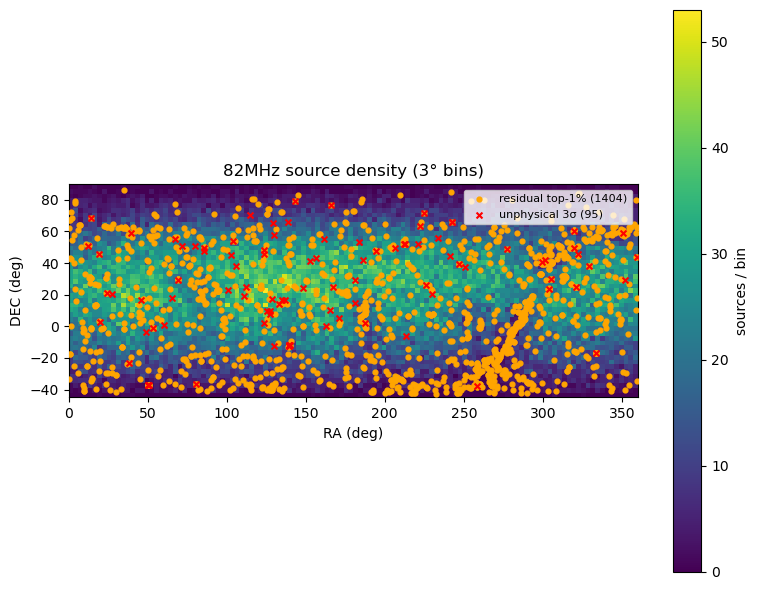


Fit-quality roll-up:


,band,n_sources,n_resid_top1,n_unphysical_3sig,max_bin_count,n_resid_and_unphysical
0,82MHz,93552,1404,95,53,43
1,78MHz,110217,1666,135,57,38
2,73MHz,104228,1577,131,56,43
3,69MHz,99443,1540,102,50,33
4,64MHz,95244,1478,69,49,23
5,59MHz,81115,1208,150,42,57
6,55MHz,74589,1137,74,42,26
7,50MHz,66173,1000,44,36,25
8,46MHz,57551,873,21,30,10
9,41MHz,49228,744,21,28,8


In [12]:
import matplotlib.pyplot as plt

# Seed-subband density map + flagged overlays; roll-up for all subbands
primary_band = SEED_BAND if SEED_BAND in lst_merged else COLOR_BANDS[0]
df_full = lst_merged[primary_band]
H, ra_edges, dec_edges = sky_density_histogram(df_full, bin_deg=DENSITY_BIN_DEG)
top_bins = densest_bins(H, ra_edges, dec_edges, n=10)
print(f"Densest {DENSITY_BIN_DEG:g}° bins ({primary_band}):")
display(top_bins)

if H.size:
    fig, ax = plt.subplots(figsize=(8, 6))
    # H is (n_ra, n_dec); pcolormesh expects X,Y as edges
    mesh = ax.pcolormesh(ra_edges, dec_edges, H.T, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label="sources / bin")
    qa = fit_qa.get(primary_band, {})
    high = qa.get("high_residual", pd.Series(False, index=df_full.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df_full.index))
    if high.any():
        ax.scatter(
            df_full.loc[high, "RA"],
            df_full.loc[high, "DEC"],
            s=12,
            c="orange",
            marker="o",
            label=f"residual top-1% ({int(high.sum())})",
            zorder=3,
        )
    if unphys.any():
        ax.scatter(
            df_full.loc[unphys, "RA"],
            df_full.loc[unphys, "DEC"],
            s=18,
            c="red",
            marker="x",
            label=f"unphysical 3σ ({int(unphys.sum())})",
            zorder=4,
        )
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("DEC (deg)")
    ax.set_title(f"{primary_band} source density ({DENSITY_BIN_DEG:g}° bins)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print(f"No finite RA/DEC for density map ({primary_band}).")

# Roll-up summary across bands
rows = []
for band in COLOR_BANDS:
    df = lst_merged[band]
    qa = fit_qa.get(band, {})
    H_b, _, _ = sky_density_histogram(df, bin_deg=DENSITY_BIN_DEG)
    max_bin = int(H_b.max()) if H_b.size else 0
    high = qa.get("high_residual", pd.Series(False, index=df.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df.index))
    rows.append(
        {
            "band": band,
            "n_sources": int(len(df)),
            "n_resid_top1": int(qa.get("n_resid_top1", high.sum())),
            "n_unphysical_3sig": int(qa.get("n_unphysical_3sig", unphys.sum())),
            "max_bin_count": max_bin,
            "n_resid_and_unphysical": int((high & unphys).sum()),
        }
    )

fit_qa_summary = pd.DataFrame(rows)
print("\nFit-quality roll-up:")
display(fit_qa_summary)
